# Preparatory and movement subspace analysis

This standalone notebook reproduces the PCA cross-projection analysis of plant inputs for all controller constraints and angles.

## Setup and reproducibility

Run this notebook from the directory containing the controller output folders. The analysis is deterministic and records package versions. Figures are displayed inline and are not saved.

In [1]:
from pathlib import Path
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

random_seed = 0
np.random.seed(random_seed)

runtime_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
}
runtime_versions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

runtime_versions["scikit_learn"] = __import__("sklearn").__version__
runtime_versions

{'python': '3.13.3',
 'numpy': '2.2.5',
 'matplotlib': '3.10.1',
 'scikit_learn': '1.6.1'}

## Data configuration

Set `data_root` to the directory containing `data_overlapping`, `data_orthogonal`, and `data_recurrence`. Set `w_type` to `non_normal` or `oscillatory`. Conditions 1, 2, and 3 correspond to $\pi/8$, $\pi/4$, and $3\pi/8$.

In [2]:
data_root = Path(".")
w_types = ("non_normal", "oscillatory")
w_type = "oscillatory"
controller_types = ("overlapping", "orthogonal", "recurrence")
angle_indices = (1, 2, 3)
angle_labels = {1: "π/8", 2: "π/4", 3: "3π/8"}
controller_labels = {
    "overlapping": "Overlapping-constrained",
    "orthogonal": "Orthogonal-constrained",
    "recurrence": "Recurrence-constrained",
}
controller_paths = {
    "overlapping": ("data_overlapping", "overlapping"),
    "orthogonal": ("data_orthogonal", "orthogonal"),
    "recurrence": ("data_recurrence", "recurrence"),
}

if w_type not in w_types:
    raise ValueError("w_type must be non_normal or oscillatory")

## Load and validate plant inputs

Each condition must contain a go-cue trajectory and a two-dimensional plant-input trajectory with matching time lengths.

In [3]:
def input_paths(controller_name, condition_index):
    directory_name, file_label = controller_paths[controller_name]
    directory = data_root / directory_name / w_type
    return {
        "gocue": directory / f"gocue_{file_label}_{condition_index}.npy",
        "uinput": directory / f"uinput_traj_{file_label}_{condition_index}.npy",
    }


def load_input_data():
    dataset = {}
    missing = []
    for controller_name in controller_types:
        for condition_index in angle_indices:
            paths = input_paths(controller_name, condition_index)
            absent = [str(path) for path in paths.values() if not path.exists()]
            if absent:
                missing.extend(absent)
                continue
            record = {name: np.load(path) for name, path in paths.items()}
            if record["gocue"].ndim != 2 or record["gocue"].shape[1] != 1:
                raise ValueError(f"invalid go-cue shape for {controller_name}, condition {condition_index}")
            if record["uinput"].ndim != 2 or record["uinput"].shape[1] != 2:
                raise ValueError(f"invalid plant-input shape for {controller_name}, condition {condition_index}")
            if record["gocue"].shape[0] != record["uinput"].shape[0]:
                raise ValueError(f"inconsistent lengths for {controller_name}, condition {condition_index}")
            dataset[(controller_name, condition_index)] = record
    if missing:
        raise FileNotFoundError("missing analysis inputs:\n" + "\n".join(missing))
    return dataset


data = load_input_data()
print(f"loaded {len(data)} controller-angle conditions for {w_type}")

loaded 9 controller-angle conditions for oscillatory


## PCA cross-projection metric

Plant inputs are standardized across the full trial. Separate two-component PCA models are fitted to preparation and movement. The first component of each model reconstructs both epochs, yielding within-epoch and cross-epoch explained variance.

In [4]:
colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(angle_indices)))


def movement_onset(record):
    indices = np.flatnonzero(record["gocue"][:, 0] >= 0.5)
    if indices.size == 0:
        raise ValueError("go cue never becomes active")
    return int(indices[0])


def component_explained_variance(values, pca_model):
    transformed = pca_model.transform(values)
    result = np.zeros(pca_model.n_components_)
    denominator = np.linalg.norm(values - pca_model.mean_) ** 2
    if denominator == 0:
        return np.full(pca_model.n_components_, np.nan)
    for component_index in range(pca_model.n_components_):
        isolated = np.zeros_like(transformed)
        isolated[:, component_index] = transformed[:, component_index]
        reconstructed = pca_model.inverse_transform(isolated)
        result[component_index] = 1.0 - np.linalg.norm(reconstructed - values) ** 2 / denominator
    return result


subspace_scores = np.zeros((len(controller_types), len(angle_indices), 2, 2))
for controller_position, controller_name in enumerate(controller_types):
    for condition_position, condition_index in enumerate(angle_indices):
        record = data[(controller_name, condition_index)]
        onset = movement_onset(record)
        standardized = StandardScaler().fit_transform(record["uinput"])
        preparation = standardized[:onset]
        movement = standardized[onset:]
        if preparation.shape[0] < 2 or movement.shape[0] < 2:
            raise ValueError(f"insufficient samples for PCA: {controller_name}, condition {condition_index}")
        preparation_pca = PCA(n_components=2, svd_solver="full").fit(preparation)
        movement_pca = PCA(n_components=2, svd_solver="full").fit(movement)
        subspace_scores[controller_position, condition_position, 0, 0] = component_explained_variance(preparation, preparation_pca)[0]
        subspace_scores[controller_position, condition_position, 0, 1] = component_explained_variance(preparation, movement_pca)[0]
        subspace_scores[controller_position, condition_position, 1, 0] = component_explained_variance(movement, preparation_pca)[0]
        subspace_scores[controller_position, condition_position, 1, 1] = component_explained_variance(movement, movement_pca)[0]

subspace_scores

array([[[[9.99942996e-01, 9.99907528e-01],
         [9.99950354e-01, 9.99997290e-01]],

        [[9.99929353e-01, 9.99886921e-01],
         [9.99949064e-01, 9.99996803e-01]],

        [[9.99942433e-01, 9.99899546e-01],
         [9.99949787e-01, 9.99997005e-01]]],


       [[[9.99999531e-01, 1.15660620e-01],
         [4.40755541e-01, 9.99982970e-01]],

        [[9.99999392e-01, 2.23212248e-02],
         [4.75486131e-01, 9.99977082e-01]],

        [[9.99999915e-01, 4.79320655e-03],
         [4.98395199e-01, 9.99971418e-01]]],


       [[[1.00000000e+00, 9.45802013e-04],
         [2.69771100e-01, 9.99999856e-01]],

        [[1.00000000e+00, 6.85330881e-04],
         [2.72910958e-01, 9.99999943e-01]],

        [[1.00000000e+00, 3.57584839e-04],
         [2.78680130e-01, 9.99999962e-01]]]])

## Cross-projection summary

Bars show the mean across angles. Colored points show individual angles. Each epoch is evaluated using both the preparation and movement subspaces.

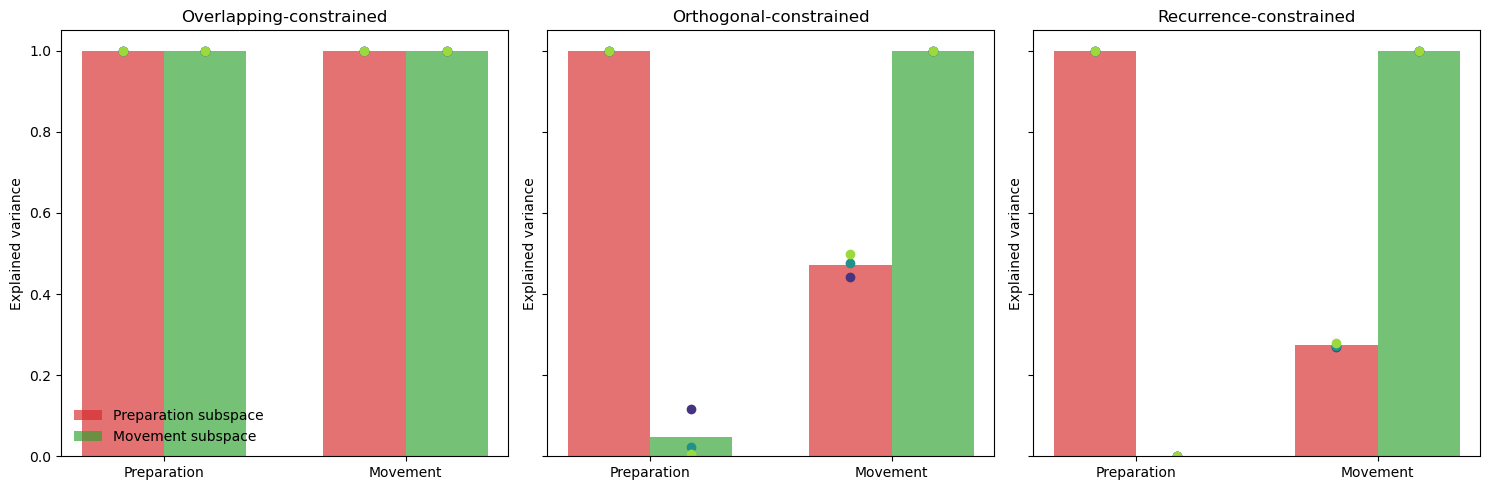

In [5]:
figure, axes = plt.subplots(1, len(controller_types), figsize=(15, 5), sharey=True)
period_positions = np.arange(2)
width = 0.34
for controller_position, controller_name in enumerate(controller_types):
    means = np.nanmean(subspace_scores[controller_position], axis=0)
    axes[controller_position].bar(period_positions - width / 2, means[:, 0], width, color="tab:red", alpha=0.65, label="Preparation subspace")
    axes[controller_position].bar(period_positions + width / 2, means[:, 1], width, color="tab:green", alpha=0.65, label="Movement subspace")
    for condition_position, condition_index in enumerate(angle_indices):
        axes[controller_position].scatter(period_positions - width / 2, subspace_scores[controller_position, condition_position, :, 0], color=colors[condition_position], zorder=2)
        axes[controller_position].scatter(period_positions + width / 2, subspace_scores[controller_position, condition_position, :, 1], color=colors[condition_position], zorder=2)
    axes[controller_position].set_xticks(period_positions, ("Preparation", "Movement"))
    axes[controller_position].set_title(controller_labels[controller_name])
    axes[controller_position].set_ylabel("Explained variance")
axes[0].legend(frameon=False)
figure.tight_layout()
plt.show()